
# Naive Bayesian Modeling for Petroleum Engineering

## Introduction to Bayesian Theory (30 minutes)

### Basics of Probability & Statistics
- Refresh on probability concepts.
- Conditional probability and statistical independence.

### Introduction to Bayesian Inference
- Principles and definition of Bayesian inference.
- Comparison between Bayesian and frequentist approaches.

## Overview of Naive Bayes Classifier (30 minutes)

### Concept and Assumptions
- Explanation and rationale behind the Naive Bayes classifier.
- Assumptions of Naive Bayes and their implications.

### Mathematical Formulation
- Detailed derivation of the Naive Bayes formula.
- Understanding of prior, likelihood, and posterior in the context.

## Naive Bayes in Machine Learning (30 minutes)

### Application in Classification Tasks
- Example: Spam filtering.AC
- Discussion on the effectiveness of Naive Bayes in different scenarios.

### Feature Engineering for Naive Bayes
- Transforming data into suitable features.
- Handling different data types: continuous vs categorical.

## Break (15 minutes)

## Naive Bayes in Petroleum Engineering (45 minutes)

### Industry-Specific Applications
- Use of Naive Bayes in data analysis for exploration and production.
- Risk assessment applications.

### Case Studies
- Real-world examples from the petroleum industry.

## Practical Session: Implementing Naive Bayes (30 minutes)

### Tools and Software
- Introduction to necessary software and libraries (Python, scikit-learn).

### Building a Naive Bayes Model
- Step-by-step guide to developing a Naive Bayes model.
- Application to a petroleum engineering dataset.

## Q&A and Wrap-Up (15 minutes)

### Open Floor for Questions
- Addressing any doubts and providing clarifications.

### Conclusion and Further Resources
- Recap of the session and direction for further learning.

# Introduction to Bayesian Theory
## Basics of Probability & Statistics

## Refresh on Probability Concepts
Probability measures the likelihood that an event will occur. It ranges from 0 (the event never occurs) to 1 (the event always occurs). Key concepts include:

- **Random Variables**: Quantifiable outcomes of random phenomena.
- **Probability Distributions**: Descriptions of how probabilities are distributed over the values of random variables.
- **Expected Value**: The long-run average value of repetitions of the experiment it represents.

## Conditional Probability and Statistical Independence
- **Conditional Probability**: The probability of an event given that another event has occurred, denoted as P(A|B).
- **Statistical Independence**: Two events are independent if the occurrence of one does not affect the probability of occurrence of the other. Mathematically, A and B are independent if P(A|B) = P(A) and P(B|A) = P(B).

# Introduction to Bayesian Inference

## Principles and Definition
Bayesian inference is a method of statistical inference in which Bayes' theorem is used to update the probability for a hypothesis as more evidence or information becomes available.

Key principles include:
- **Prior Probability**: The initial judgment before new evidence is introduced.
- **Likelihood**: How probable the new evidence is under different hypotheses.
- **Posterior Probability**: Updated probability of the hypothesis given the new evidence.

## Comparison Between Bayesian and Frequentist Approaches
- **Bayesian Approach**: Involves updating the probability estimates for hypotheses as more evidence becomes available. It is subjective and incorporates prior beliefs.
- **Frequentist Approach**: Involves testing hypotheses without considering prior probabilities. It is objective and does not change with new evidence.



In [1]:
# import necessary python libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

from IPython.display import display_svg
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_iris

/home/gensyn/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


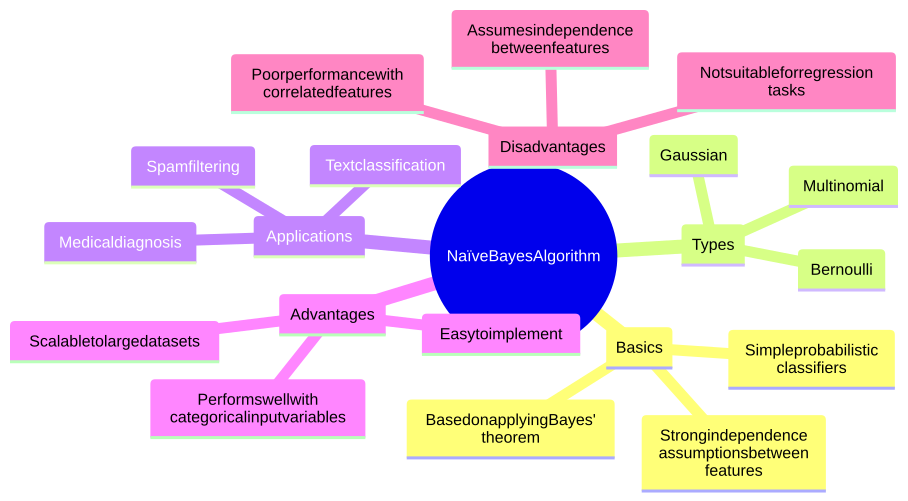

In [2]:
svg_filename = 'NaiveBayesMap.svg'
with open(svg_filename, 'r') as file:
    svg_content = file.read()

display_svg(svg_content, raw=True)

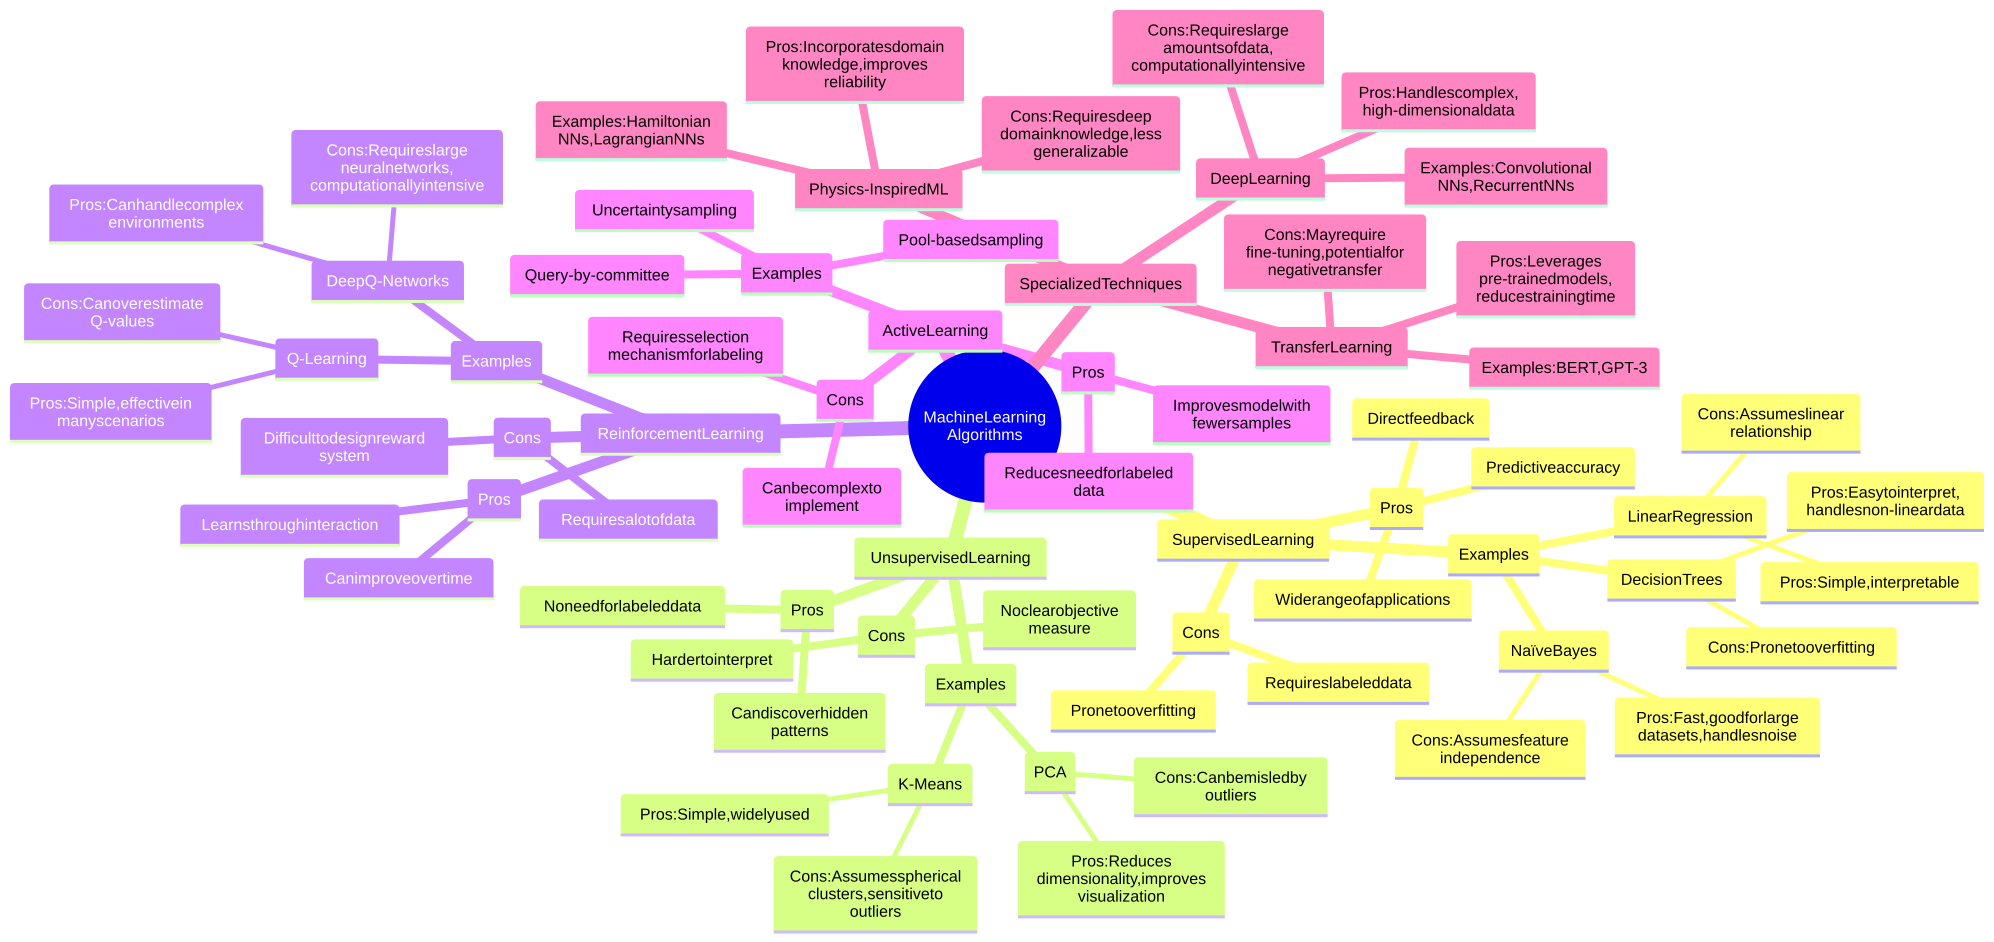

In [3]:
svg_filename = 'Unsupervised_ML_Map.svg'
with open(svg_filename, 'r') as file:
    svg_content = file.read()

display_svg(svg_content, raw=True)

In [4]:
# setup the environment needed for this tutorial
!pip install numpy pandas matplotlib seaborn scikit-learn IPython umap-learn torch torchvision -U

DEPRECATION: Loading egg at /home/gensyn/anaconda3/lib/python3.11/site-packages/deepspeed-0.8.3-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/gensyn/anaconda3/lib/python3.11/site-packages/progressbar-2.5-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/gensyn/anaconda3/lib/python3.11/site-packages/transformers-4.31.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/gensyn/anaconda3/lib/python3.11/site-packages/rotary_embedding_to

DEPRECATION: torchsde 0.2.5 has a non-standard dependency specifier numpy>=1.19.*; python_version >= "3.7". pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of torchsde or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


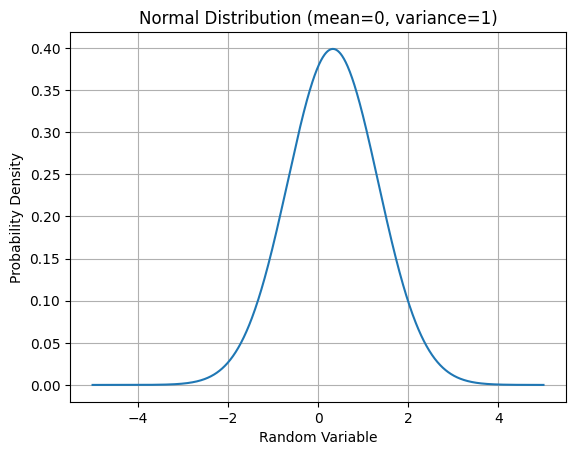

In [5]:
# Random Variables & Probability Distributions
# Let's use a normal distribution as an example
mean, variance = 0.33, 1
normal_distribution = stats.norm(mean, variance)

# Plot the probability distribution
x_values = np.linspace(-5, 5, 1000)
y_values = normal_distribution.pdf(x_values)
plt.plot(x_values, y_values)
plt.title('Normal Distribution (mean=0, variance=1)')
plt.xlabel('Random Variable')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

In [6]:
# Expected Value
# For a normal distribution, the expected value is the mean
expected_value = normal_distribution.mean()
print(f'Expected Value: {expected_value}')

Expected Value: 0.33


In [7]:
# Conditional Probability & Statistical Independence
# Example with two coin flips
# P(Second = Heads | First = Heads) and P(Second = Heads)
# Assuming independence, these probabilities should be equal

prob_second_given_first = 0.5  # Since coin flips are independent
prob_second = 0.5  # Probability of heads in a fair coin

print(f'P(Second=Heads | First=Heads): {prob_second_given_first}')
print(f'P(Second=Heads): {prob_second}')

P(Second=Heads | First=Heads): 0.5
P(Second=Heads): 0.5


In [8]:
# Introduction to Bayesian Inference
# Prior Probability (belief before evidence)
prior_probability = 0.5  # Let's assume a 50-50 prior belief

# Likelihood (chance of observing the data given the hypothesis)
likelihood = 0.8  # Hypothetically, if the hypothesis were true

# Evidence (overall probability of observing the data)
evidence = 0.7  # Hypothetically, observed data probability

# Posterior Probability (updated belief after considering the evidence)
posterior_probability = (likelihood * prior_probability) / evidence
print(f'Posterior Probability: {posterior_probability}')

# Comparison Between Bayesian and Frequentist Approaches
# Bayesian approach updates the belief based on new evidence
# Frequentist approach would test the hypothesis without prior probabilities

Posterior Probability: 0.5714285714285715


In this Python code:

We've demonstrated how a normal distribution can represent a probability distribution for a random variable.
We've calculated and printed the expected value (mean) for the distribution.
We showed an example of conditional probability and statistical independence using coin flips.
We introduced Bayesian inference by calculating the posterior probability from a prior probability, likelihood, and evidence.
The distinction between Bayesian and frequentist approaches is explained in comments, showing how Bayesian inference updates beliefs with evidence, while frequentist statistics focuses on hypothesis testing without prior beliefs.

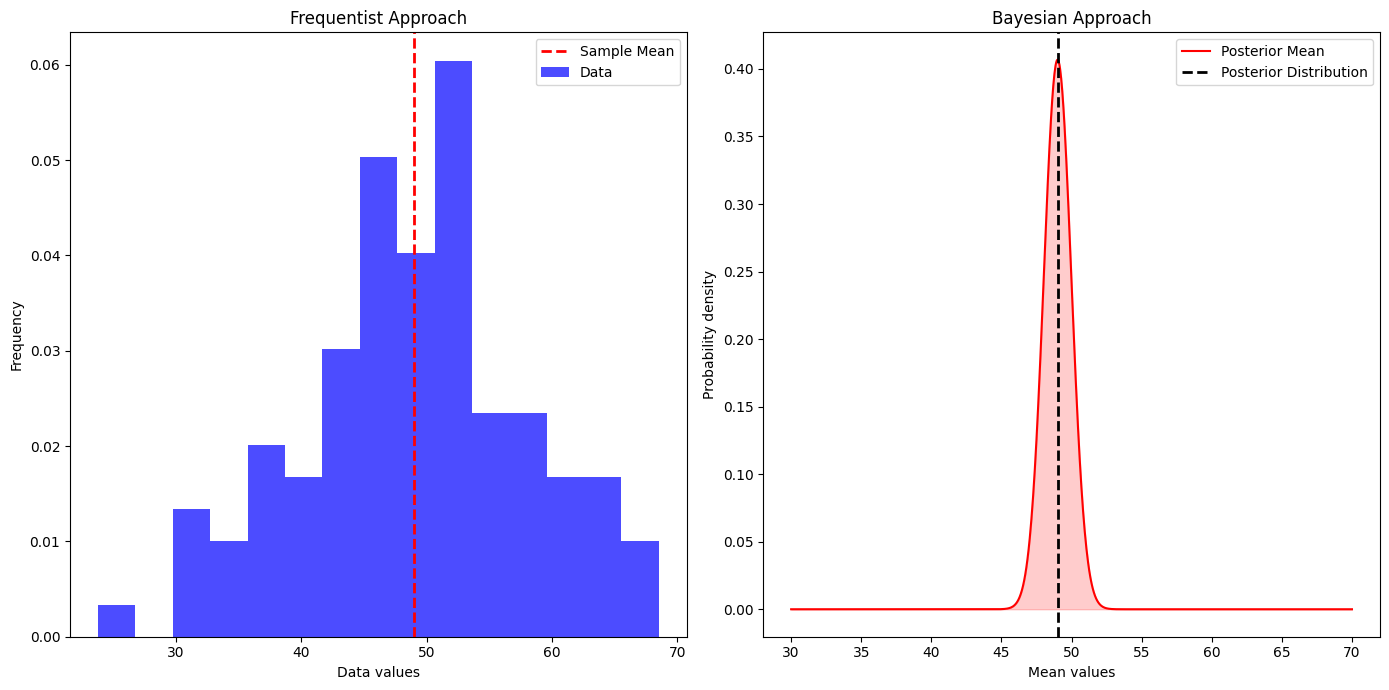

Frequentist estimate of the mean: 48.96153482605907
Bayesian estimate of the mean: 49.00147579428755


In [9]:
# Simulate sample data: true mean is 50, standard deviation is 10
np.random.seed(42)
sample_size = 100
data = np.random.normal(50, 10, sample_size)

# Frequentist approach: estimate the mean using sample mean
frequentist_mean = np.mean(data)

# Bayesian approach: assume prior for mean is also normal (e.g., N(50, 25))
# We use a conjugate prior for simplicity; in this case, it's also Normal
prior_mean, prior_variance = 50, 25
likelihood_variance = 10 ** 2  # assuming we know the true variance
posterior_variance = 1 / (1 / prior_variance + sample_size / likelihood_variance)
posterior_mean = (prior_mean / prior_variance + sum(data) / likelihood_variance) * posterior_variance

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Data histogram and Frequentist mean
ax[0].hist(data, bins=15, density=True, alpha=0.7, color='blue')
ax[0].axvline(frequentist_mean, color='red', linestyle='dashed', linewidth=2)
ax[0].title.set_text('Frequentist Approach')
ax[0].set_xlabel('Data values')
ax[0].set_ylabel('Frequency')
ax[0].legend(['Sample Mean', 'Data'])

# Bayesian posterior distribution
x_values = np.linspace(30, 70, 1000)
posterior_pdf = stats.norm.pdf(x_values, posterior_mean, np.sqrt(posterior_variance))
ax[1].plot(x_values, posterior_pdf, 'r-')
ax[1].title.set_text('Bayesian Approach')
ax[1].set_xlabel('Mean values')
ax[1].set_ylabel('Probability density')
ax[1].axvline(posterior_mean, color='black', linestyle='dashed', linewidth=2)
ax[1].fill_between(x_values, posterior_pdf, 0, alpha=0.2, color='red')
ax[1].legend(['Posterior Mean', 'Posterior Distribution'])

plt.tight_layout()
plt.show()

print(f"Frequentist estimate of the mean: {frequentist_mean}")
print(f"Bayesian estimate of the mean: {posterior_mean}")

# Overview of Naive Bayes Classifier
## Concept and Assumptions of Naive Bayes Classifier

## Explanation and Rationale
The Naive Bayes classifier is a probabilistic machine learning model used for classification tasks. It applies Bayes' Theorem, incorporating the 'naive' assumption of conditional independence between every pair of features given the class label. This simplification makes Naive Bayes easy to implement and understand, particularly suitable for high-dimensional datasets.

## Assumptions of Naive Bayes and Their Implications
1. **Conditional Independence**: Assumes all features are independent of each other, given the class. While this is rarely true in real data, Naive Bayes can still perform well.
2. **Feature Relevance**: Assumes all features contribute equally to the outcome. In reality, some features may be more relevant than others.

# Mathematical Formulation of Naive Bayes

## Detailed Derivation
Given a class variable \( Y \) and a dependent feature vector \( X_1, X_2, ..., X_n \), Bayes' Theorem states:

\[ P(Y|X) = rac{P(X|Y)P(Y)}{P(X)} \]

However, calculating \( P(X|Y) \) directly is complex. Assuming conditional independence (naive assumption), we can simplify:

\[ P(X|Y) = P(X_1|Y) 	imes P(X_2|Y) 	imes ... 	imes P(X_n|Y) \]

Thus, the Naive Bayes classification becomes:

\[ P(Y|X) = rac{P(Y) 	imes \prod_{i=1}^{n}P(X_i|Y)}{P(X)} \]

Since \( P(X) \) is constant for all classes, we focus on maximizing \( P(Y) 	imes \prod_{i=1}^{n}P(X_i|Y) \).

## Understanding Prior, Likelihood, and Posterior
- **Prior (P(Y))**: The initial probability of the class before observing the data.
- **Likelihood (\( \prod_{i=1}^{n}P(X_i|Y) \))**: The probability of the data given the class.
- **Posterior (P(Y|X))**: The updated probability of the class given the observed data.

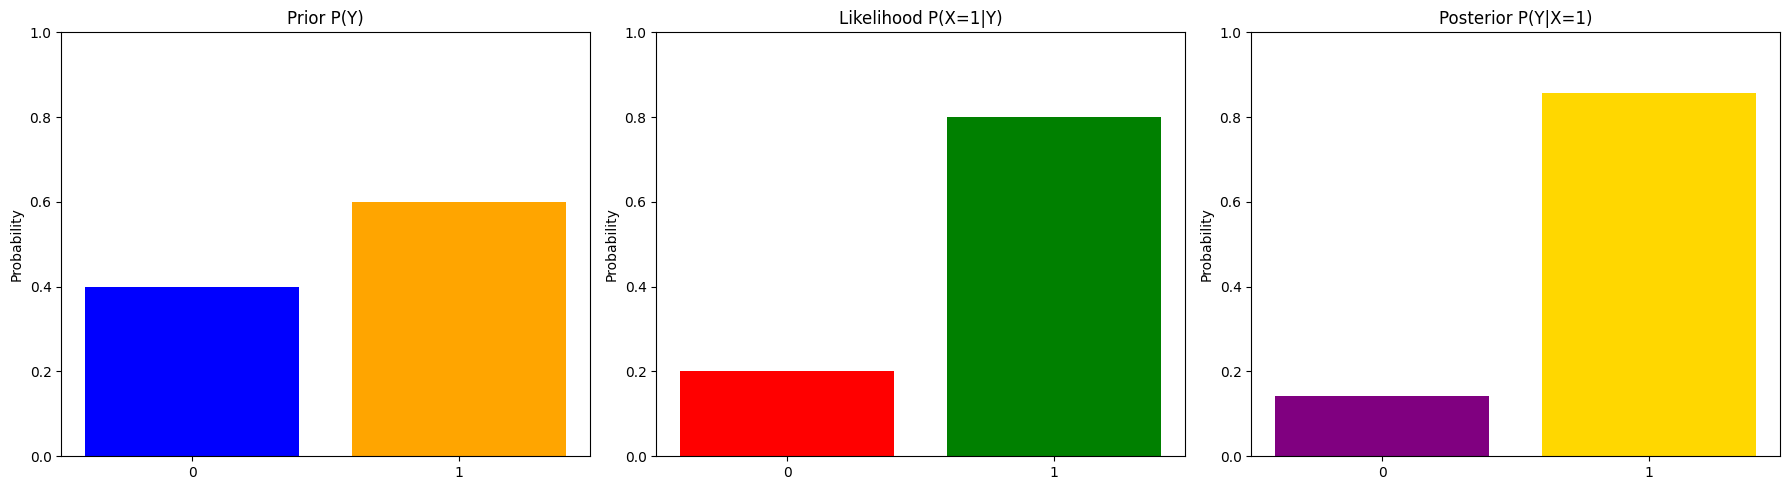

Posterior Probability (P(Y=1|X=1)): 0.86


In [10]:
# Set up the scenario
prior_prob = 0.6  # Prior probability of class 1 (P(Y=1))
likelihood_prob = 0.8  # Likelihood of observing feature given class 1 (P(X=1|Y=1))

# Assuming binary feature and class, calculate posterior probability for class 1 when feature is 1
posterior_prob = (likelihood_prob * prior_prob) / ((likelihood_prob * prior_prob) + (1-likelihood_prob) * (1-prior_prob))

# Generate data for visualization
x = np.array([0, 1])  # Possible outcomes: 0 for class 0, 1 for class 1

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Prior
axes[0].bar(x, [1-prior_prob, prior_prob], color=['blue', 'orange'])
axes[0].set_title('Prior P(Y)')
axes[0].set_xticks(x)
axes[0].set_ylim([0, 1])
axes[0].set_ylabel('Probability')

# Plot Likelihood (assuming binary outcome, with complement for class 0)
axes[1].bar(x, [1-likelihood_prob, likelihood_prob], color=['red', 'green'])
axes[1].set_title('Likelihood P(X=1|Y)')
axes[1].set_xticks(x)
axes[1].set_ylim([0, 1])
axes[1].set_ylabel('Probability')

# Plot Posterior
axes[2].bar(x, [1-posterior_prob, posterior_prob], color=['purple', 'gold'])
axes[2].set_title('Posterior P(Y|X=1)')
axes[2].set_xticks(x)
axes[2].set_ylim([0, 1])
axes[2].set_ylabel('Probability')

plt.tight_layout()
plt.show()

print(f"Posterior Probability (P(Y=1|X=1)): {posterior_prob:.2f}")

We compute the posterior probability explicitly for Y=1 given X=1.

We plot the prior probability for both classes, the likelihood of X=1 given each class, and finally, the posterior probabilities for both classes.

This visualization should help in understanding the transformation from prior to posterior probabilities upon observing new evidence (feature X=1).

# Naive Bayes in Machine Learning 

### Loading and Preparing the Data
For this example, we'll use the Iris dataset, which is a classic dataset in machine learning but imagine it as different types of rocks or geological samples, which is a simplification but helps to illustrate the process. In petroleum engineering, similar classification tasks could involve categorizing rock samples based on seismic attributes.

In [11]:
# Load the dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display the first few rows of the dataframe
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Data Visualization
Visualizing the data can help in understanding the distribution and relation between different features.

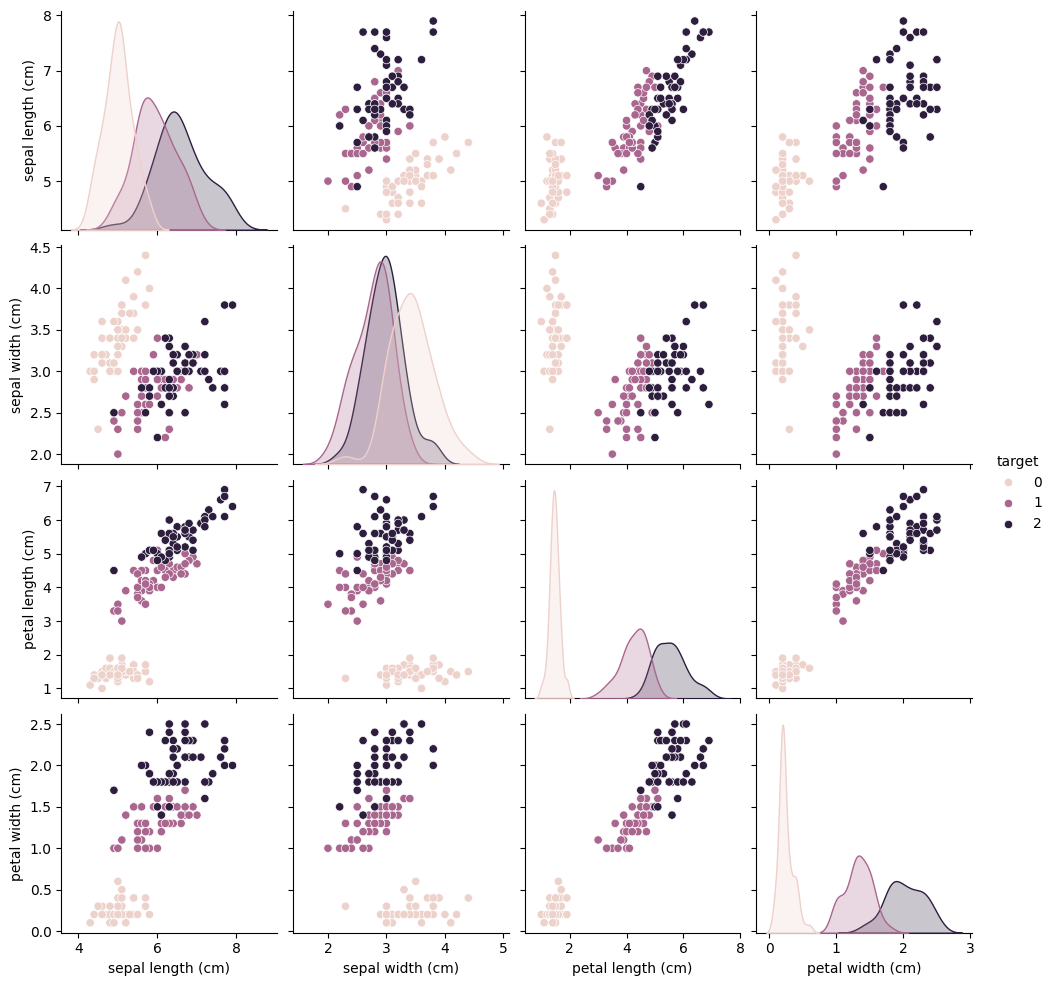

In [12]:
# Pairplot to visualize the attributes' distribution
sns.pairplot(df, hue='target')
plt.show()


## Detailed Explanation of Data Visualization

Data visualization plays a critical role in both data analysis and machine learning, as it aids in deciphering the underlying patterns and connections within the data. The specific visualizations mentioned, such as pair plots, are matrices of graphs that illustrate the pairwise relationships between multiple variables in a dataset.

### Variables in the Iris Dataset

1. **Petal Length**: Represents the length of the flower petal.
2. **Petal Width**: Represents the width of the flower petal.
3. **Sepal Length**: Represents the length of the sepal, which is the part of the plant that encloses the bud.
4. **Sepal Width**: Represents the width of the sepal.

These are analogous to various measurable properties in geological samples or seismic attributes in petroleum engineering.

### Significance of Pair Plots

1. **Understanding Relationships**: They help identify how each variable relates to others, aiding in inferring correlations between them.
2. **Identifying Patterns**: Useful in recognizing different clusters or groupings in the data, which in real-world applications could differentiate between rock types or reservoir characteristics.
3. **Spotting Anomalies**: Outliers or unusual data points become evident, highlighting possible data errors or important variations.
4. **Feature Selection**: By identifying variables that have significant relationships with the target variable, effective predictors for machine learning models can be chosen.
5. **Distribution Insights**: The diagonal often shows each variable's distribution, providing insights into skewness, kurtosis, and overall shape, which are crucial for model performance.

In essence, pair plots offer a comprehensive overview of the dataset's characteristics, crucial for informed decision-making and effective modeling in complex domains like petroleum engineering.

### Preparing Data for Naive Bayes
Split the dataset into training and testing sets:

In [13]:
X = df.drop('target', axis=1)
y = df['target']
# The random state is a seed for reproduceability.  
# The answer is 42 comes from the hitch hikers guide to the galaxy sci-fi novel.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Training the Naive Bayes Model
Now, we'll train a Naive Bayes classifier using the training data.

In [14]:
# Initialize the classifier
gnb = GaussianNB()

# Train the classifier
model = gnb.fit(X_train, y_train)

### Making Predictions and Evaluating the Model
After training the model, we'll use it to make predictions on the test set and evaluate its performance.

In [15]:
# Making predictions
y_pred = model.predict(X_test)

# Evaluating the model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



## Understanding the Output from Predictions: Classification Metrics

In machine learning, particularly in classification tasks, evaluating the performance of a model is crucial. The metrics typically used for this evaluation include precision, recall, f1-score, and support. Each of these metrics provides different insights into the model's performance.

### Precision
- **Definition**: Precision measures the accuracy of positive predictions. It is the ratio of true positive predictions to the total positive predictions (including both true positives and false positives).
- **Formula**: Precision = True Positives / (True Positives + False Positives)
- **Usefulness**: High precision indicates a low rate of false positives. This metric is crucial in scenarios where the cost of false positives is high.

### Recall (Sensitivity or True Positive Rate)
- **Definition**: Recall measures the ability of the classifier to find all the positive samples. It is the ratio of true positives to the actual total positives (including both true positives and false negatives).
- **Formula**: Recall = True Positives / (True Positives + False Negatives)
- **Usefulness**: High recall indicates a low rate of false negatives. This metric is essential in situations where missing a positive instance is costly.

### F1-Score
- **Definition**: The F1-score is the harmonic mean of precision and recall, providing a single score that balances both the concerns of precision and recall in one number.
- **Formula**: F1 = 2 * (Precision * Recall) / (Precision + Recall)
- **Usefulness**: The F1-score is useful when you want to balance precision and recall. It is particularly important when there is an uneven class distribution (e.g., when one class is much rarer than the other).

### Support
- **Definition**: Support is the number of actual occurrences of the class in the specified dataset. For each class, it shows the number of instances that are correctly predicted and misclassified.
- **Usefulness**: Support gives a sense of the size of the dataset from which the metrics are derived. This can be important to identify imbalances in the dataset where one class is significantly more represented than others.

These metrics together provide a comprehensive picture of the model performance, helping identify areas of strength and weakness, which is essential for further tuning and improvement.

### Visualizing the Results
It's often helpful to visualize the results to understand the model's performance better.

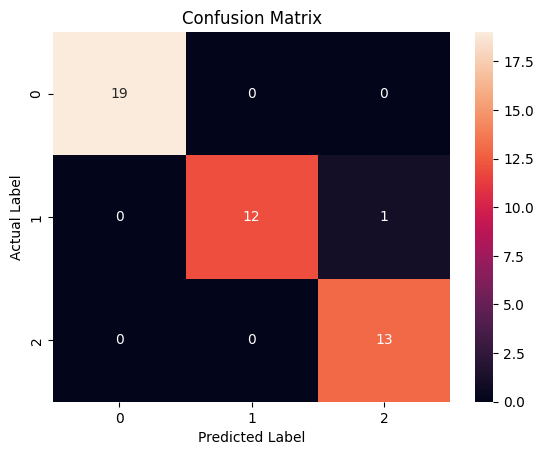

In [16]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Naive Bayes in Petroleum Engineering

Creating an advanced example relevant to petroleum engineering involves several steps. For this, we'll use a typical scenario in petroleum engineering: predicting well performance based on certain features. Since we don't have direct access to specific petroleum engineering datasets due to restrictions, let's simulate this by using a hypothetical but representative dataset that could resemble real-world petroleum engineering data. The features might include geological properties, well design parameters, and operational variables.

For educational purposes, I'll outline how you could structure this example, including the data gathering, preprocessing, model training, and evaluation phases. I'll provide Python code snippets that you can adapt and run in a Jupyter Notebook. Please note, the actual data and specific details should be replaced with real data from your context:

- **Data Gathering**:  Typically, you'd gather data from databases containing well logs, production history, and other relevant information. For our example, let's assume we have a CSV file well_performance.csv with columns like RockPorosity, Permeability, WellDepth, OperationalDays, OilProductionRate.

- **Data Preprocessing**:  This includes cleaning the data, handling missing values, and encoding categorical variables if necessary.

- **Feature Selection**:  Based on domain knowledge, select the most relevant features that are likely to influence the well's performance.

- **Model Training**:  We'll use a Naive Bayes classifier for this task, even though in real scenarios, other models might be more appropriate based on the data characteristics.

- **Model Evaluation**:  We'll evaluate the model using precision, recall, f1-score, and support.

In [17]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Load the dataset (this is simulated randomly, we do not expect good performance)
df = pd.read_csv('well_performance.csv')

# Preprocessing
# Assume 'RockPorosity', 'Permeability', 'WellDepth', 'OperationalDays' are features
# and 'OilProductionRate' is the target variable (categorized as High, Medium, Low)
X = df[['RockPorosity', 'Permeability', 'WellDepth', 'OperationalDays']]
y = df['OilProductionRate']  # You might need to categorize this variable based on your criteria

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the Naive Bayes classifier
model = GaussianNB()
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.25      0.31      0.28        90
         Low       0.38      0.46      0.42       107
      Medium       0.32      0.19      0.24       103

    accuracy                           0.32       300
   macro avg       0.32      0.32      0.31       300
weighted avg       0.32      0.32      0.32       300



### Scenario and Data Simulation:
Let's consider a hypothetical situation in petroleum engineering: predicting the success of drilling operations based on geological and operational parameters. We will simulate data for this scenario as real-world data may not be publicly available. The features might include geological characteristics (like rock porosity and permeability), operational parameters (like drill speed and time), and historical success rates.

Here are the simulated factors:

- **Rock Porosity** (continuous):  Porosity of the rock formations.
- **Permeability** (continuous): Rock permeability in millidarcies.
- **Drill Speed** (continuous): Speed of the drilling operation.
- **Operational days** (continuous): Days required for the operation.
- **Success** (binary): Whether the drilling operation was successful (1) or not (0).
Note: In a real-world scenario, you would replace this with actual data and potentially more relevant features.

Python Simulation and Analysis:
Since we're creating a hypothetical example, the following code will simulate data for this scenario, apply Naive Bayes, and visualize the results:

              precision    recall  f1-score   support

           0       0.61      0.21      0.31       176
           1       0.42      0.81      0.55       124

    accuracy                           0.46       300
   macro avg       0.51      0.51      0.43       300
weighted avg       0.53      0.46      0.41       300



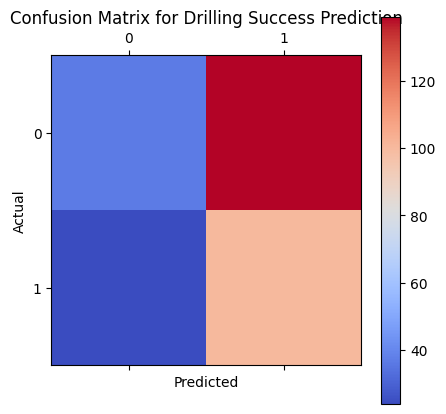

In [18]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Simulate data
np.random.seed(42)
n_samples = 1000
data = {
    'RockPorosity': np.random.uniform(0.1, 0.3, n_samples),  # Porosity ranges from 10% to 30%
    'Permeability': np.random.uniform(50, 200, n_samples),  # Permeability ranges
    'DrillSpeed': np.random.uniform(100, 200, n_samples),  # Drill speed
    'OperationalDays': np.random.randint(30, 180, n_samples),  # Operation days
    'Success': np.random.binomial(1, 0.5, n_samples)  # Success or failure
}
df = pd.DataFrame(data)

# Preprocessing and data split
features = df.drop('Success', axis=1)
labels = df['Success']
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)

# Apply Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualization of results
plt.figure(figsize=(5,5))
plt.matshow(conf_matrix, cmap='coolwarm', fignum=1)
plt.title('Confusion Matrix for Drilling Success Prediction')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Industry-Specific Applications and Case Studies:
**Exploration and Production Data Analysis**: In this simulated scenario, Naive Bayes helps predict drilling success based on geological and operational parameters. This parallels real-world applications where similar predictive models might inform decisions about where and how to drill.

**Risk Assessment and Decision-Making Under Uncertainty**: The output from the Naive Bayes model (probabilities of success or failure) can be used in risk assessment, helping engineers and decision-makers weigh the potential rewards against the risks of different drilling operations.

**Case Studies**: While this example is hypothetical, in real-life, models like these could be used to analyze past drilling operations, optimizing future strategies based on the learned probabilities. For example, a petroleum company might use historical data to train a Naive Bayes model, then apply this model to assess the viability of new drilling sites.

# Unsupervised Learning Examples
## K-Means Clustering

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fdd9acdbd80>
Traceback (most recent call last):
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attr

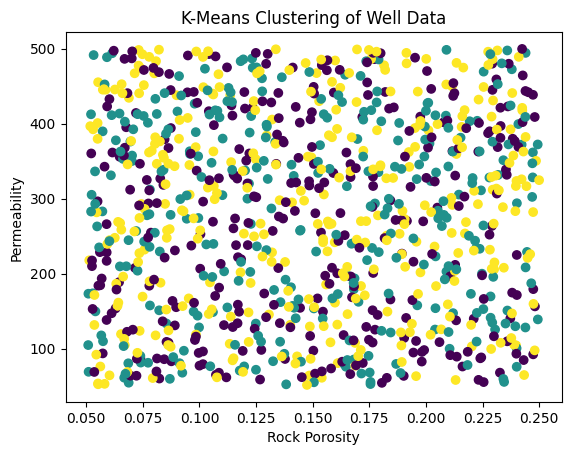

In [19]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('well_performance.csv')

# Assume these are the features for clustering
X = df[['RockPorosity', 'Permeability', 'WellDepth', 'OperationalDays']]

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Visualizing the clusters
plt.scatter(df['RockPorosity'], df['Permeability'], c=df['Cluster'])
plt.xlabel('Rock Porosity')
plt.ylabel('Permeability')
plt.title('K-Means Clustering of Well Data')
plt.show()


## Principal Component Analysis (PCA)

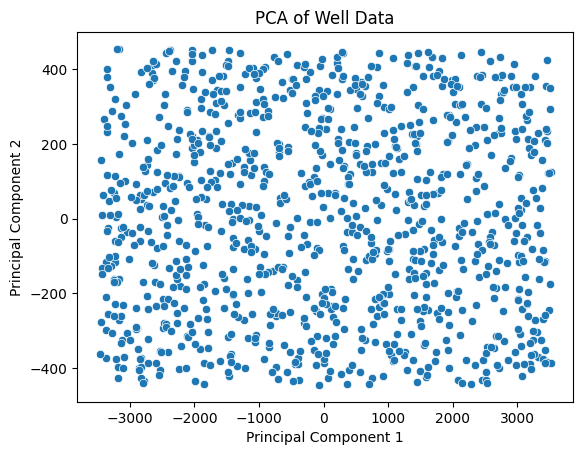

In [20]:
from sklearn.decomposition import PCA
import seaborn as sns

# PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualizing the PCA-reduced data
df_pca = pd.DataFrame(data = X_pca, columns = ['Principal Component 1', 'Principal Component 2'])
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=df_pca)
plt.title('PCA of Well Data')
plt.show()

## t-Distributed Stochastic Neighbor Embedding (t-SNE):

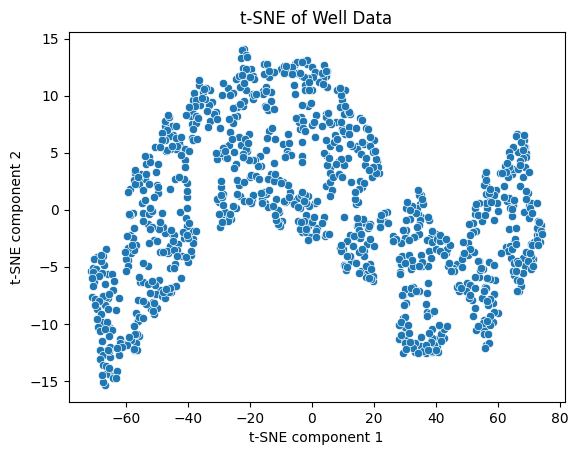

In [21]:
from sklearn.manifold import TSNE

# t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Visualizing the t-SNE reduced data
df_tsne = pd.DataFrame(data = X_tsne, columns = ['t-SNE component 1', 't-SNE component 2'])
sns.scatterplot(x='t-SNE component 1', y='t-SNE component 2', data=df_tsne)
plt.title('t-SNE of Well Data')
plt.show()

## Uniform Manifold Approximation and Projection (UMAP):

2024-03-16 15:54:21.340064: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


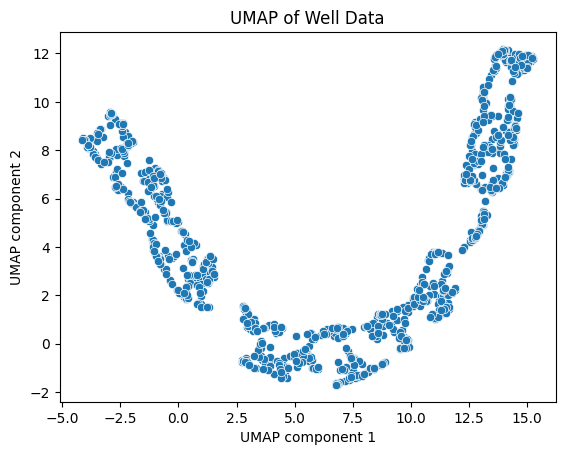

In [22]:
import umap

# UMAP for dimensionality reduction
reducer = umap.UMAP()
X_umap = reducer.fit_transform(X)

# Visualizing the UMAP reduced data
df_umap = pd.DataFrame(data = X_umap, columns = ['UMAP component 1', 'UMAP component 2'])
sns.scatterplot(x='UMAP component 1', y='UMAP component 2', data=df_umap)
plt.title('UMAP of Well Data')
plt.show()

## Deep Learning (using a simple deep neural network as an example):

In [23]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Ensure running on CPU
# os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Load the dataset
df = pd.read_csv('well_performance.csv')

# Preprocessing
X = df[['RockPorosity', 'Permeability', 'WellDepth', 'OperationalDays']].values
y = df['WellDepth'].values  # Replace 'WellDepth' with your continuous target variable

# Data scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = y.reshape(-1, 1)  # y should be a 2D array for the scaler
y_scaled = scaler.fit_transform(y_scaled).ravel()  # Back to 1D array

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # Convert to 2D tensor for the loss function
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

# Define the neural network
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(4, 5)  # 4 input features
        self.fc2 = nn.Linear(5, 5)
        self.fc3 = nn.Linear(5, 1)  # Output one continuous variable

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # No activation for the final layer in regression
        return x

# Initialize the network and optimizer
net = Net()
criterion = nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Training the network
num_epochs = 50
for epoch in range(num_epochs):
    for data in train_loader:
        inputs, targets = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

# Evaluation (we won't do backpropagation, hence torch.no_grad())
with torch.no_grad():
    predicted = net(X_test)
    # Compute error
    test_loss = criterion(predicted, y_test)
    print(f'Test MSE: {test_loss.item()}')

Test MSE: 0.08761491626501083


# The examples above using a real dataset, iris
## K-Means Clustering with Iris Dataset:

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fdcd9487ec0>
Traceback (most recent call last):
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attr

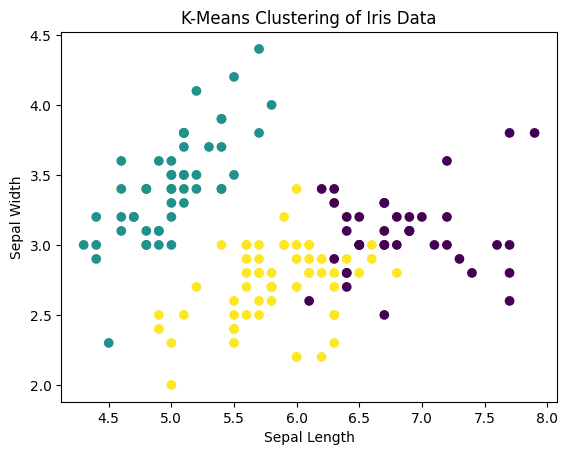

In [25]:
from sklearn import datasets
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load the iris dataset
iris = datasets.load_iris()
X = iris.data

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Visualizing the clusters
plt.scatter(X[:, 0], X[:, 1], c=clusters)  # Plot using the first two features
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering of Iris Data')
plt.show()

## Principal Component Analysis (PCA) with Iris Dataset:

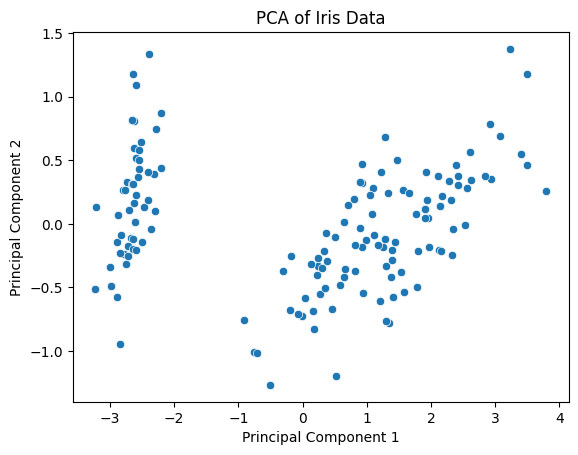

In [26]:
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd

# PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualizing the PCA-reduced data
df_pca = pd.DataFrame(data = X_pca, columns = ['Principal Component 1', 'Principal Component 2'])
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=df_pca)
plt.title('PCA of Iris Data')
plt.show()

## t-Distributed Stochastic Neighbor Embedding (t-SNE) with Iris Dataset:

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fdc8857b420>
Traceback (most recent call last):
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/gensyn/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attr

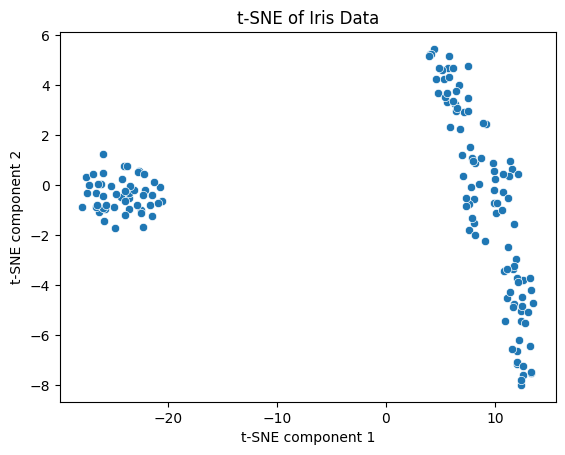

In [27]:
from sklearn.manifold import TSNE

# t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Visualizing the t-SNE reduced data
df_tsne = pd.DataFrame(data = X_tsne, columns = ['t-SNE component 1', 't-SNE component 2'])
sns.scatterplot(x='t-SNE component 1', y='t-SNE component 2', data=df_tsne)
plt.title('t-SNE of Iris Data')
plt.show()

## Uniform Manifold Approximation and Projection (UMAP) with Iris Dataset:

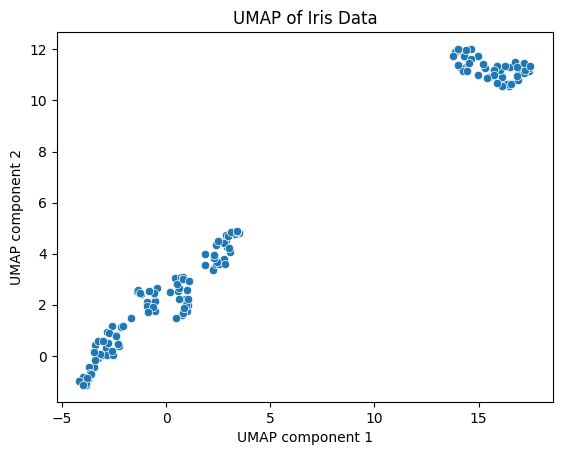

In [29]:
import umap.umap_ as umap

# UMAP for dimensionality reduction
reducer = umap.UMAP()
X_umap = reducer.fit_transform(X)

# Visualizing the UMAP reduced data
df_umap = pd.DataFrame(data = X_umap, columns = ['UMAP component 1', 'UMAP component 2'])
sns.scatterplot(x='UMAP component 1', y='UMAP component 2', data=df_umap)
plt.title('UMAP of Iris Data')
plt.show()

## Deep Learning Example with Iris Dataset:

In [31]:
import torch
from torch import nn
from sklearn.preprocessing import MinMaxScaler

# Load the iris dataset
iris = datasets.load_iris()
X = iris.data

# Data scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(4, 5)  # First layer
        self.fc2 = nn.Linear(5, 5)  # Second layer
        self.fc3 = nn.Linear(5, 2)  # Output layer for 2D representation
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # No activation here, as this is for visualization
        return x

# Initialize and apply the network
model = SimpleNN()
outputs = model(X_tensor).detach().numpy()  # Convert outputs to NumPy array for plotting

# Output
print(outputs)

[[ 1.06247127e-01  1.13833547e-02]
 [ 1.22630492e-01  6.70823455e-03]
 [ 1.19326577e-01  1.39080584e-02]
 [ 1.25700116e-01  1.08306855e-02]
 [ 1.05159730e-01  1.30746365e-02]
 [ 9.39197391e-02  1.04201287e-02]
 [ 1.16459668e-01  1.64958388e-02]
 [ 1.11048356e-01  1.14644468e-02]
 [ 1.29394054e-01  1.57916099e-02]
 [ 1.20780230e-01  8.38972628e-03]
 [ 9.73226875e-02  9.07543302e-03]
 [ 1.14762202e-01  1.32368058e-02]
 [ 1.24045402e-01  8.60843062e-03]
 [ 1.28807217e-01  1.74011439e-02]
 [ 8.14242065e-02  7.76606798e-03]
 [ 7.50759542e-02  1.10673308e-02]
 [ 9.10226703e-02  1.18596554e-02]
 [ 1.06403559e-01  1.17904097e-02]
 [ 9.18611288e-02  6.18956983e-03]
 [ 9.93812829e-02  1.33060217e-02]
 [ 1.06521919e-01  6.46822155e-03]
 [ 1.02119923e-01  1.30879283e-02]
 [ 1.08241796e-01  1.87785774e-02]
 [ 1.17092818e-01  1.54536963e-03]
 [ 1.16935000e-01  1.21571720e-02]
 [ 1.21709704e-01  5.47164679e-03]
 [ 1.13166153e-01  8.81485641e-03]
 [ 1.05476618e-01  9.95735824e-03]
 [ 1.07334509e-01  9

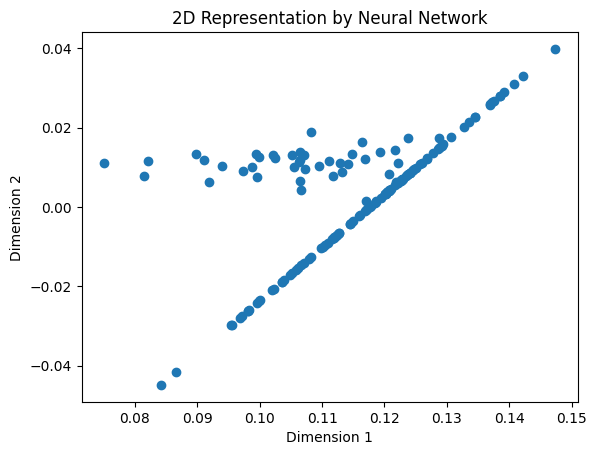

In [32]:
import matplotlib.pyplot as plt

# Assuming outputs are the 2D reductions from the neural network
plt.scatter(outputs[:, 0], outputs[:, 1])
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('2D Representation by Neural Network')
plt.show()

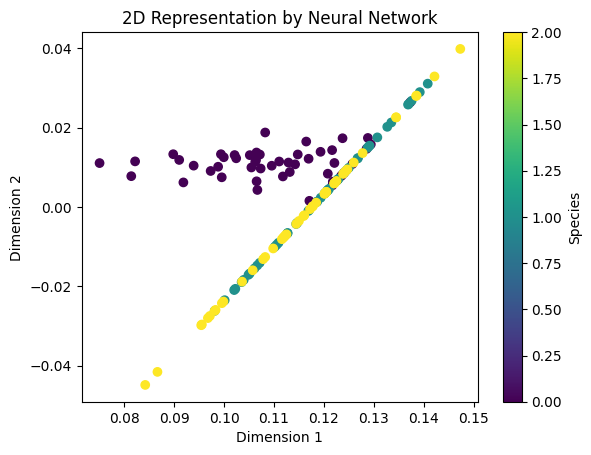

In [34]:
# Plotting the outputs in a scatter plot
# Here, the actual labels are used for coloring the points.
plt.scatter(outputs[:, 0], outputs[:, 1], c=iris.target, cmap='viridis')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('2D Representation by Neural Network')
plt.colorbar(label='Species')
plt.show()

In [35]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load the iris dataset
iris = datasets.load_iris()
X = iris.data  # Assuming we use all features for prediction
y = iris.data[:, 0]  # Let's predict sepal length for demonstration; normally, you'd predict species

# Split the dataset into a training set and a testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict the values for the testing set
predictions = model.predict(X_test)

# Actual values are simply y_test from the split
actuals = y_test

# Optionally calculate and print the Mean Squared Error for evaluation
mse = mean_squared_error(actuals, predictions)
print(f'Mean Squared Error: {mse}')

# Now 'actuals' and 'predictions' contain the actual and predicted values, respectively


Mean Squared Error: 4.733165431326071e-30


## Line Plot for Actual vs. Predicted:
This line plot directly compares actual and predicted values. It's especially useful for sequential data (like time series), but can be adapted for other types of regression data by sorting or just plotting the sequence of observations.

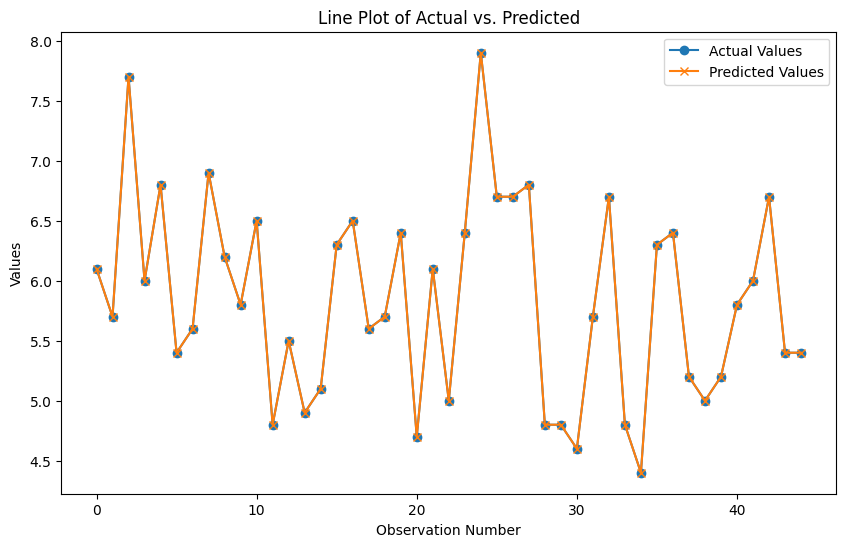

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(actuals, label='Actual Values', linestyle='-', marker='o')
plt.plot(predictions, label='Predicted Values', linestyle='-', marker='x')
plt.xlabel('Observation Number')
plt.ylabel('Values')
plt.title('Line Plot of Actual vs. Predicted')
plt.legend()
plt.show()

## Residual Plot:
The residual plot can help identify patterns in the residuals, which can indicate issues with model fit, such as non-linearity, heteroscedasticity, or outliers.

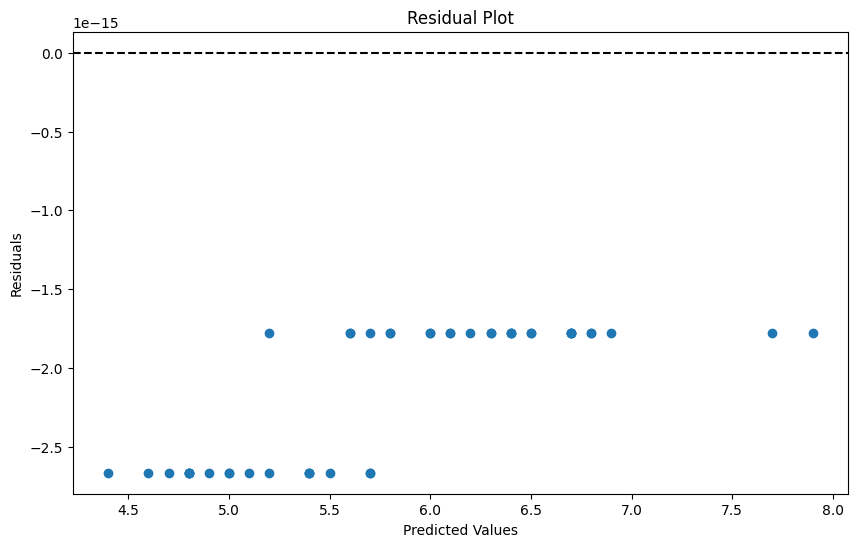

In [37]:
residuals = actuals - predictions

plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='k', linestyle='--')  # Line at zero to show perfect prediction
plt.show()

## Bland-Altman Plot (Mean-Difference Plot):
The Bland-Altman plot is used to assess the agreement between two sets of measurements. It is particularly useful in medical statistics but can be adapted for any regression model comparison. The plot shows the average of the actual and predicted values against their difference, highlighting whether there is a systematic bias and whether the extent of disagreement is related to the magnitude of the measurements.

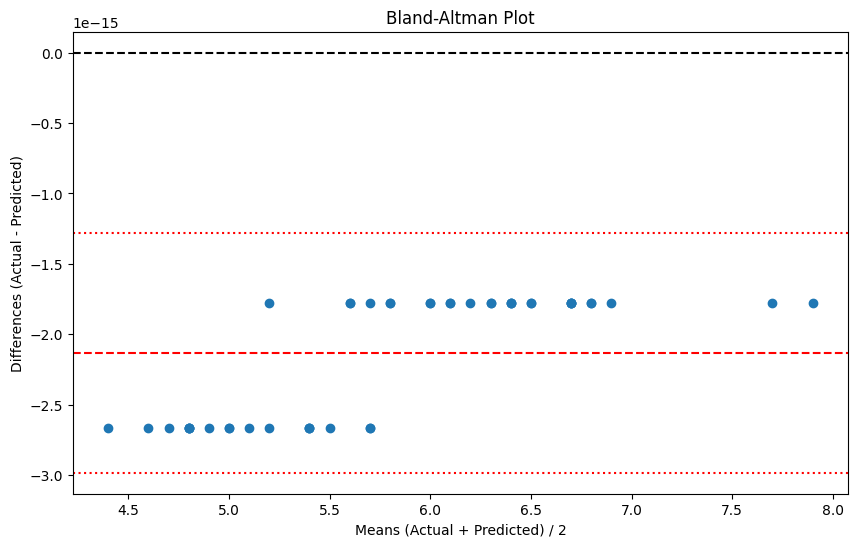

In [38]:
means = (actuals + predictions) / 2
differences = actuals - predictions

plt.figure(figsize=(10, 6))
plt.scatter(means, differences)
plt.xlabel('Means (Actual + Predicted) / 2')
plt.ylabel('Differences (Actual - Predicted)')
plt.axhline(y=0, color='k', linestyle='--')  # Line at zero difference
plt.axhline(y=np.mean(differences), color='r', linestyle='--')  # Mean difference
plt.axhline(y=np.mean(differences) + 1.96*np.std(differences), color='r', linestyle=':')  # Upper limit of agreement
plt.axhline(y=np.mean(differences) - 1.96*np.std(differences), color='r', linestyle=':')  # Lower limit of agreement
plt.title('Bland-Altman Plot')
plt.show()